In [1]:
# ── Importing Essentials ─────────────────────────────────────
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
 
import warnings
warnings.filterwarnings("ignore")

In [2]:
train_dir = "brain_tumor_dataset/Training"
test_dir  = "brain_tumor_dataset/Testing"
os.makedirs("outputs", exist_ok=True)
os.makedirs("models",  exist_ok=True)

In [3]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30

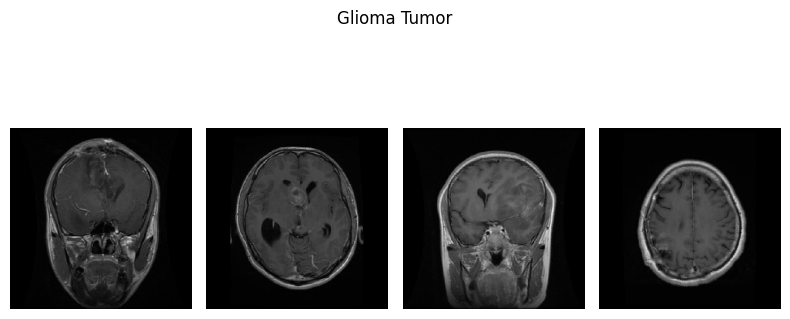

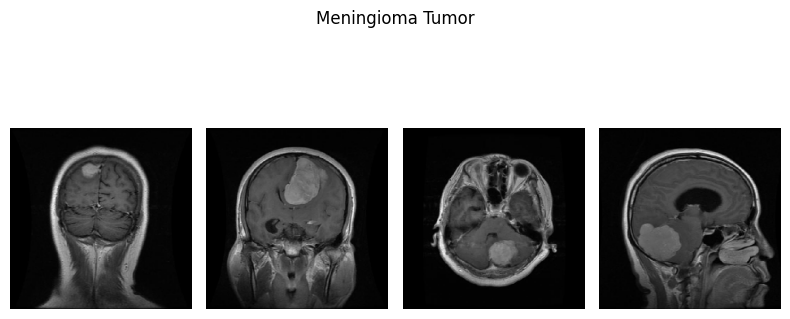

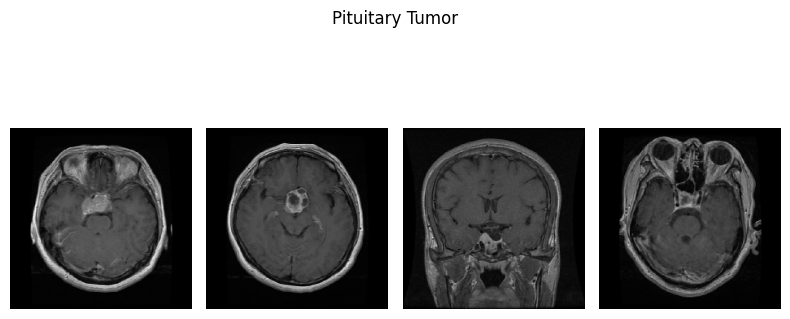

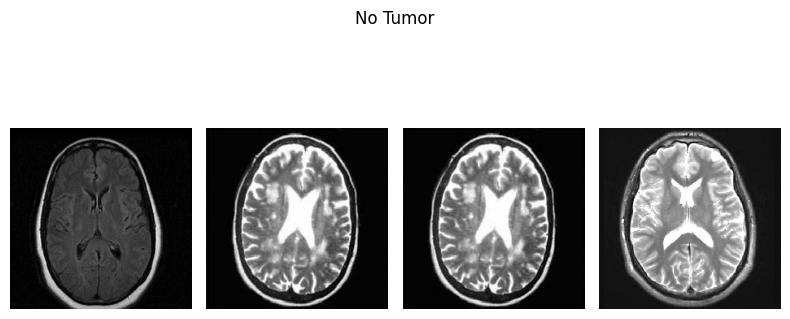

In [4]:
def show_images(folder, label):
    plt.figure(figsize=(8, 4))
    files = [f for f in os.listdir(folder)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    for i in range(4):
        img = load_img(os.path.join(folder, random.choice(files)),
                       target_size=(224, 224))
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(label)
    plt.tight_layout()
    plt.show()
 
show_images(train_dir + "/glioma",      "Glioma Tumor")
show_images(train_dir + "/meningioma",  "Meningioma Tumor")
show_images(train_dir + "/pituitary",   "Pituitary Tumor")
show_images(train_dir + "/notumor",     "No Tumor")

In [5]:
print("── Class distribution ──")
for split, directory in [("Training", train_dir), ("Testing", test_dir)]:
    print(f"\n{split}:")
    for cls in sorted(os.listdir(directory)):
        path = os.path.join(directory, cls)
        if os.path.isdir(path):
            count = len([f for f in os.listdir(path)
                         if f.lower().endswith((".jpg", ".jpeg", ".png"))])
            print(f"  {cls:15s}: {count} images")

── Class distribution ──

Training:
  glioma         : 1400 images
  meningioma     : 1400 images
  notumor        : 1400 images
  pituitary      : 1400 images

Testing:
  glioma         : 400 images
  meningioma     : 400 images
  notumor        : 400 images
  pituitary      : 400 images


In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    shear_range=0.1,
    fill_mode="nearest"
)

In [7]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
 
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=True,
    seed=42
)
 
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False
)
 
print("\nClass indices (label → index):")
print(train_data.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class indices (label → index):
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [10]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False
 
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(4, activation="softmax")(x)
 
model = models.Model(inputs=base_model.input, outputs=output)
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,624,452 (10.01 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("models",  exist_ok=True)
 
callbacks_phase1 = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("models/best_phase1.keras",
                    monitor="val_accuracy",
                    save_best_only=True, verbose=1)
]

In [13]:
print("\n── Phase 1: Training classifier head (base frozen) ──")
history1 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=callbacks_phase1
)


── Phase 1: Training classifier head (base frozen) ──
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8690 - loss: 0.3434
Epoch 1: val_accuracy improved from 0.81000 to 0.85500, saving model to models/best_phase1.keras

Epoch 1: finished saving model to models/best_phase1.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8707 - loss: 0.3486 - val_accuracy: 0.8550 - val_loss: 0.4567 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.8856 - loss: 0.3044
Epoch 2: val_accuracy did not improve from 0.85500
175/175 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.8852 - loss: 0.3105 - val_accuracy: 0.8469 - val_loss: 0.4682 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.9020 - loss: 0.2600
Epoch 3: val_accuracy did not improve from 0.85500
175/175 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8980 - loss: 0.2664 - val_accuracy: 0.8519 - val_loss: 0.4429 - learning_rate: 0.0010

In [14]:
print("\n── Phase 2: Fine-tuning top layers ──")
base_model.trainable = True
 
for layer in base_model.layers[:-30]:
    layer.trainable = False
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
callbacks_phase2 = [
    EarlyStopping(monitor="val_loss", patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint("models/best_phase2.keras",
                    monitor="val_accuracy",
                    save_best_only=True, verbose=1)
]
 
history2 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS,
    callbacks=callbacks_phase2
)


── Phase 2: Fine-tuning top layers ──
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8487 - loss: 0.3999
Epoch 1: val_accuracy improved from None to 0.88063, saving model to models/best_phase2.keras

Epoch 1: finished saving model to models/best_phase2.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.8707 - loss: 0.3476 - val_accuracy: 0.8806 - val_loss: 0.4040 - learning_rate: 1.0000e-05
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8986 - loss: 0.2896
Epoch 2: val_accuracy did not improve from 0.88063
175/175 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.8930 - loss: 0.2887 - val_accuracy: 0.8781 - val_loss: 0.4124 - learning_rate: 1.0000e-05
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9069 - loss: 0.2496
Epoch 3: val_accuracy improved from 0.88063 to 0.88625, saving model to models/best_phase2.keras

Epoch 3: finished saving model to models/best_phase2.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy

In [16]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged
 
full_history = merge_histories(history1, history2)

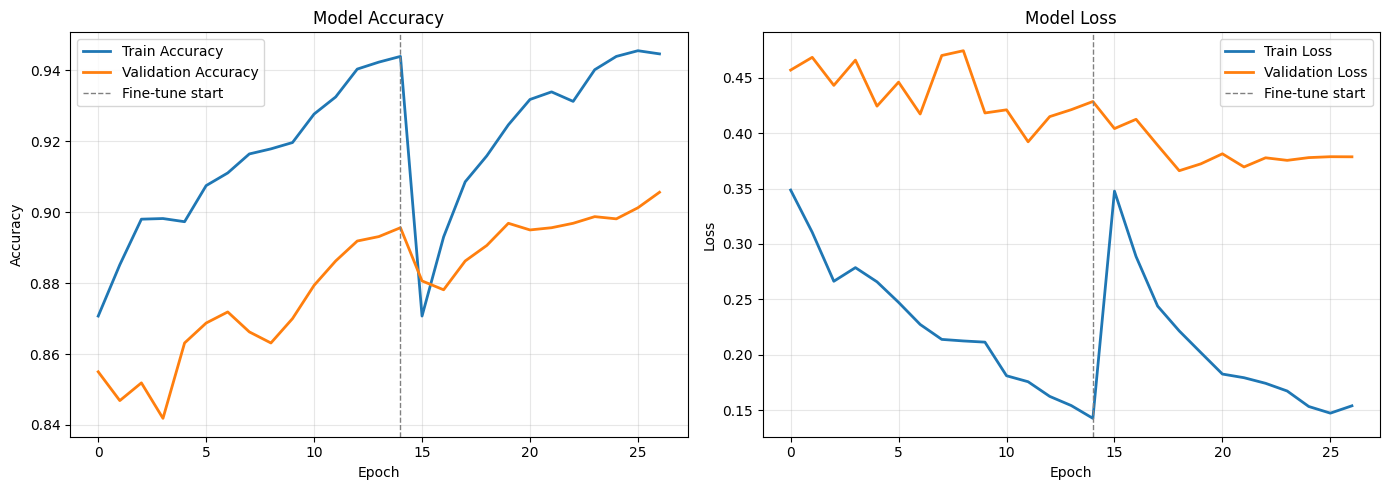

Saved → outputs/accuracy_loss_graph.png


In [17]:
plt.figure(figsize=(14, 5))
 
plt.subplot(1, 2, 1)
plt.plot(full_history["accuracy"],     label="Train Accuracy",      linewidth=2)
plt.plot(full_history["val_accuracy"], label="Validation Accuracy", linewidth=2)
phase1_end = len(history1.history["accuracy"])
plt.axvline(x=phase1_end - 1, color="gray", linestyle="--",
            linewidth=1, label="Fine-tune start")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
 
plt.subplot(1, 2, 2)
plt.plot(full_history["loss"],     label="Train Loss",      linewidth=2)
plt.plot(full_history["val_loss"], label="Validation Loss", linewidth=2)
plt.axvline(x=phase1_end - 1, color="gray", linestyle="--",
            linewidth=1, label="Fine-tune start")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("outputs/accuracy_loss_graph.png", dpi=150)
plt.show()
print("Saved → outputs/accuracy_loss_graph.png")

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 364ms/step


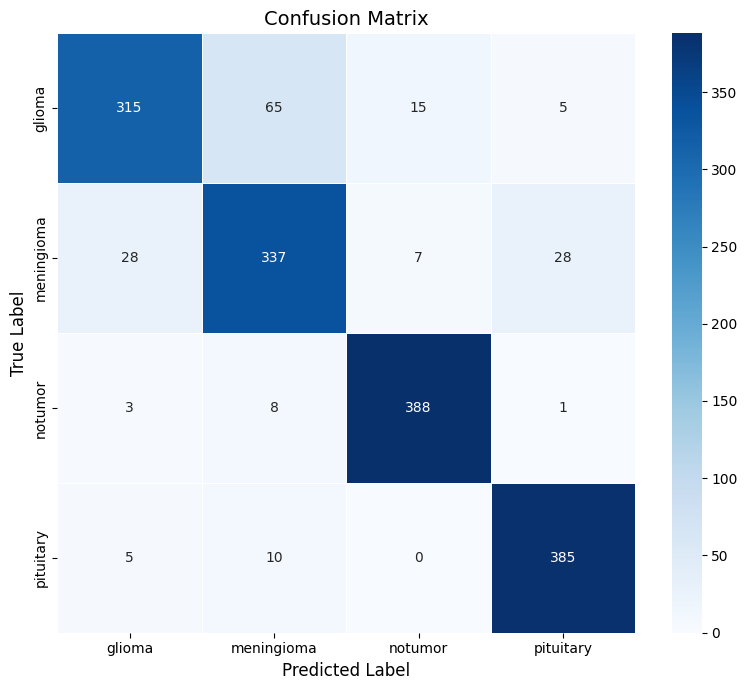

Saved → outputs/confusion_matrix.png


In [18]:
test_data.reset()
predictions     = model.predict(test_data, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes      = test_data.classes
class_labels      = [k for k, v in sorted(train_data.class_indices.items(),
                                           key=lambda item: item[1])]
 
cm = confusion_matrix(true_classes, predicted_classes)
 
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label",      fontsize=12)
plt.title("Confusion Matrix",  fontsize=14)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()
print("Saved → outputs/confusion_matrix.png")

In [19]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)
print("\nClassification Report:")
print(report)
 
with open("outputs/classification_report.txt", "w") as f:
    f.write(report)
print("Saved → outputs/classification_report.txt")


Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.79      0.84       400
  meningioma       0.80      0.84      0.82       400
     notumor       0.95      0.97      0.96       400
   pituitary       0.92      0.96      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600

Saved → outputs/classification_report.txt


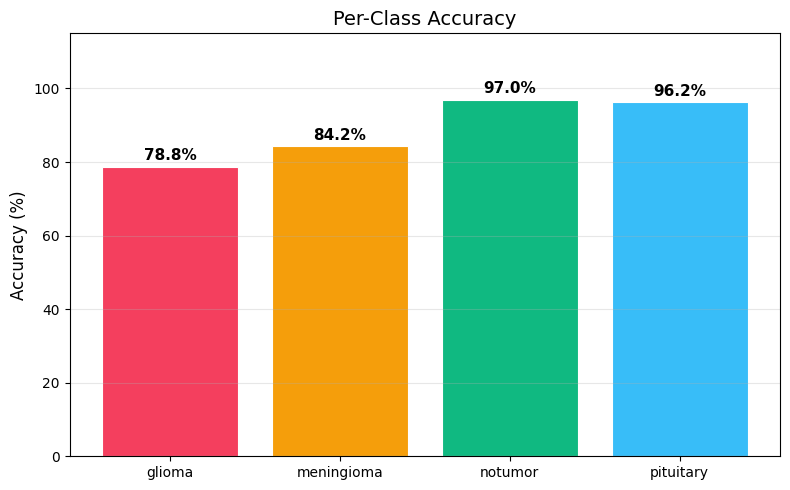

Saved → outputs/per_class_accuracy.png


In [20]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
 
plt.figure(figsize=(8, 5))
bars = plt.bar(class_labels, per_class_acc * 100,
               color=["#f43f5e", "#f59e0b", "#10b981", "#38bdf8"],
               edgecolor="white", linewidth=0.8)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{acc*100:.1f}%",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.ylim(0, 115)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Per-Class Accuracy", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/per_class_accuracy.png", dpi=150)
plt.show()
print("Saved → outputs/per_class_accuracy.png")

In [21]:
model.save("models/brain_tumor_classifier_model.h5")
print("\nModel saved → models/brain_tumor_classifier_model.h5")
 
print("\nFinal class index mapping (use this in the Streamlit app):")
for name, idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    print(f"  {idx}: {name}")


Model saved → models/brain_tumor_classifier_model.h5

Final class index mapping (use this in the Streamlit app):
  0: glioma
  1: meningioma
  2: notumor
  3: pituitary


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
eval_data = eval_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
 
loss, accuracy = model.evaluate(eval_data)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.8906 - loss: 0.3660

Test Accuracy: 89.06%
